# 🎮 Steam Game Market Analysis
**โปรเจคจบสาย Data Analyst — วิเคราะห์ตลาดเกมบน Steam**

### คำถามทางธุรกิจ (Business Questions)
สมมติว่าเราเป็นนักวิเคราะห์ให้ **สตูดิโอเกมอินดี้ไทย** ที่กำลังตัดสินใจว่าจะสร้างเกมถัดไปแบบไหน

1. ตลาดเกมบน Steam เติบโตอย่างไร? การแข่งขันสูงขึ้นแค่ไหน?
2. **แนวเกมไหนน่าลงทุน** — คู่แข่งน้อยแต่ผลตอบแทนดี?
3. **ตั้งราคาเท่าไรดี** สำหรับเกมอินดี้?
4. Indie vs AA vs AAA — รายได้กระจุกตัวแค่ไหน?
5. Free-to-Play คุ้มกว่าขายขาดไหม?
6. **ปัจจัยอะไรสัมพันธ์กับการเป็นเกมฮิต** (Multiplayer, ภาษาไทย, Early Access, Steam Deck)?

> ข้อมูล: `data/games.csv` (ข้อมูลสังเคราะห์สำหรับฝึก) — เปลี่ยน `DATA_FILE` เป็น `data/steam_real.csv` ที่ได้จาก `scripts/fetch_steam_data.py` เพื่อใช้ข้อมูลจริง
>
> นิยาม **Hit** = รีวิวเชิงบวก ≥ 80% และผู้เล่น ≥ 100,000 คน

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_FILE = ROOT / "data" / "games.csv"          # หรือ ROOT / "data" / "steam_real.csv"
FIG_DIR = ROOT / "analysis" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .3, "figure.dpi": 110})
BLUE, ORANGE, GREEN, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#b4bac4"

def save(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

pd.options.display.float_format = "{:,.2f}".format
df_raw = pd.read_csv(DATA_FILE)
print(df_raw.shape)
df_raw.head()

(2512, 20)


,app_id,name,release_date,primary_genre,developer_tier,price_usd,price_range,is_free,early_access,multiplayer,thai_language,steam_deck,owners_estimate,positive_reviews,negative_reviews,review_pct,avg_playtime_hours,peak_ccu,estimated_revenue_usd,success
0,166045,Neon Empire Deluxe,2022-01-22,Adventure,Indie,4.99,< $5,Paid,No,No,No,Verified,3100,60,25,71.70,15.00,11,5599,Not hit
1,170596,Solar Frontier: Origins II,2017-08-01,Action,AA,0.00,Free,Free,No,No,Yes,Unsupported,41773400,684407,183030,78.90,10.60,65132,31055226,Not hit
2,187394,Broken Dungeon Deluxe,2025-01-28,Horror,Indie,4.99,< $5,Paid,Yes,No,No,Playable,23900,705,132,84.30,32.90,80,48577,Not hit
3,185840,Shadow Dungeon Remastered Remastered,2018-10-28,Simulation,Indie,0.00,Free,Free,No,No,No,Verified,33100,929,334,73.60,31.10,42,53354,Not hit
4,112839,Broken Frontier Deluxe,2022-09-21,RPG,Indie,0.00,Free,Free,No,Yes,No,Unsupported,65500,1063,504,67.90,48.60,162,85484,Not hit


## 1. สำรวจและทำความสะอาดข้อมูล (Data Cleaning)

In [2]:
print("ชนิดข้อมูล:\n", df_raw.dtypes, "\n")
print("ค่าว่างต่อคอลัมน์:\n", df_raw.isna().sum()[lambda s: s > 0], "\n")
print("แถวซ้ำ:", df_raw.duplicated().sum())

ชนิดข้อมูล:
 app_id                     int64
name                         str
release_date                 str
primary_genre                str
developer_tier               str
price_usd                float64
price_range                  str
is_free                      str
early_access                 str
multiplayer                  str
thai_language                str
steam_deck                   str
owners_estimate            int64
positive_reviews           int64
negative_reviews           int64
review_pct               float64
avg_playtime_hours       float64
peak_ccu                   int64
estimated_revenue_usd      int64
success                      str
dtype: object 

ค่าว่างต่อคอลัมน์:
 thai_language         14
steam_deck            20
avg_playtime_hours    24
dtype: int64 

แถวซ้ำ: 12


In [3]:
df = df_raw.drop_duplicates().copy()
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year

# ค่าว่าง: playtime เติมด้วยมัธยฐานของแนวเกมเดียวกัน, คอลัมน์ข้อความเติม "Unknown"
if "avg_playtime_hours" in df:
    df["avg_playtime_hours"] = df.groupby("primary_genre")["avg_playtime_hours"].transform(lambda s: s.fillna(s.median()))
for c in ["steam_deck", "thai_language"]:
    if c in df:
        df[c] = df[c].fillna("Unknown")
df = df.dropna(subset=["owners_estimate", "review_pct"])
df["is_hit"] = (df["success"] == "Hit").astype(int)

log = f"เดิม {len(df_raw):,} แถว → ลบแถวซ้ำ {df_raw.duplicated().sum()} แถว → เหลือ {len(df):,} แถว"
print(log)
df.describe().T

เดิม 2,512 แถว → ลบแถวซ้ำ 12 แถว → เหลือ 2,500 แถว


,count,mean,min,25%,50%,75%,max,std
app_id,"2,500.00","146,268.50","100,037.00","123,152.75","146,268.50","169,384.25","192,500.00","26,707.79"
release_date,2500,2021-10-06 09:57:53.280000,2016-01-04 00:00:00,2019-07-24 18:00:00,2022-02-21 00:00:00,2024-02-18 06:00:00,2025-12-30 00:00:00,NaN
price_usd,"2,500.00",13.76,0.00,4.99,9.99,19.99,69.99,13.63
owners_estimate,"2,500.00","316,750.24",200.00,"3,800.00","14,950.00","68,625.00","41,773,400.00","2,013,595.98"
positive_reviews,"2,500.00","6,882.40",1.00,69.00,296.00,"1,402.00","1,108,509.00","44,207.81"
negative_reviews,"2,500.00","1,662.22",1.00,25.00,86.00,397.50,"198,703.00","9,919.29"
review_pct,"2,500.00",74.09,26.70,66.80,73.95,81.70,99.00,10.76
avg_playtime_hours,"2,500.00",26.52,0.90,7.90,15.80,35.52,507.70,28.99
peak_ccu,"2,500.00","1,050.23",0.00,8.00,35.00,187.25,"160,396.00","7,978.96"
estimated_revenue_usd,"2,500.00","3,754,315.38",63.00,"9,427.75","46,497.00","267,098.75","1,035,891,654.00","35,505,714.48"


**ข้อสังเกต:** `owners_estimate` และ `estimated_revenue_usd` มีค่าเฉลี่ยสูงกว่ามัธยฐานหลายเท่า → ข้อมูล **เบ้ขวามาก (long tail)**
จึงควรสรุปด้วย **มัธยฐาน** และพล็อตด้วย **log scale**

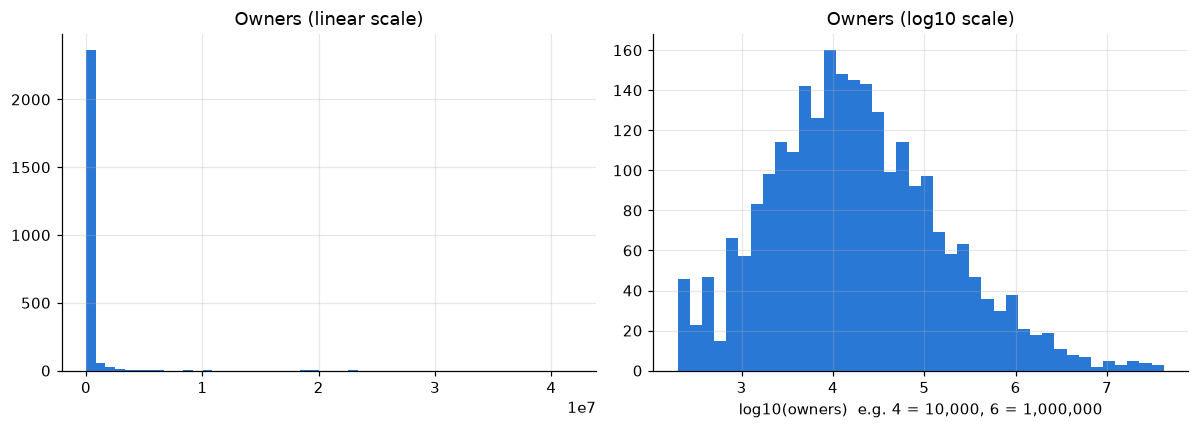

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["owners_estimate"], bins=50, color=BLUE)
axes[0].set_title("Owners (linear scale)")
axes[1].hist(np.log10(df["owners_estimate"].clip(lower=1)), bins=40, color=BLUE)
axes[1].set_title("Owners (log10 scale)")
axes[1].set_xlabel("log10(owners)  e.g. 4 = 10,000, 6 = 1,000,000")
save("01_owners_distribution")

## 2. ตลาดเติบโตอย่างไร? (Q1)

,games,median_owners,hit_rate,games_growth_%
release_year,,,,
2016,141,"24,800.00",0.12,NaN
2017,172,"17,700.00",0.12,21.99
2018,188,"17,750.00",0.11,9.30
2019,225,"14,100.00",0.11,19.68
2020,219,"18,200.00",0.05,-2.67
2021,258,"15,050.00",0.10,17.81
2022,301,"12,800.00",0.09,16.67
2023,335,"17,800.00",0.10,11.30
2024,324,"11,450.00",0.08,-3.28


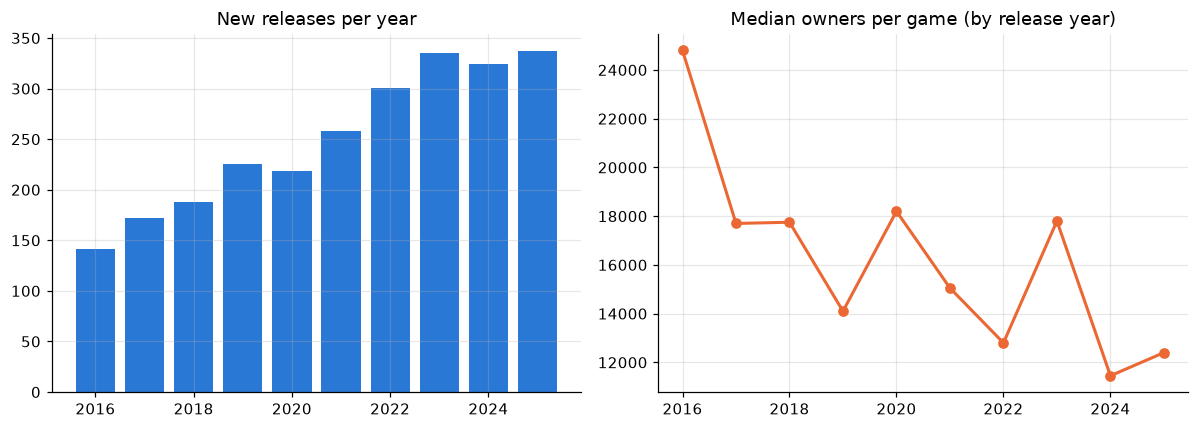

In [5]:
yearly = df.groupby("release_year").agg(
    games=("app_id", "size"),
    median_owners=("owners_estimate", "median"),
    hit_rate=("is_hit", "mean"),
)
yearly["games_growth_%"] = yearly["games"].pct_change() * 100
display(yearly)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(yearly.index, yearly["games"], color=BLUE)
axes[0].set_title("New releases per year")
axes[1].plot(yearly.index, yearly["median_owners"], color=ORANGE, marker="o", lw=2)
axes[1].set_title("Median owners per game (by release year)")
save("02_market_growth")

**Insight:** จำนวนเกมใหม่เพิ่มขึ้นทุกปี แต่ผู้เล่นต่อเกม (มัธยฐาน) ไม่ได้เพิ่มตาม → **การแข่งขันสูงขึ้น** เกมใหม่ต้องแย่งความสนใจมากขึ้น
(หมายเหตุ: เกมที่ออกนานกว่าก็มีเวลาสะสมผู้เล่นนานกว่า ควรกล่าวถึงข้อจำกัดนี้ในรายงาน)

## 3. แนวเกมไหนน่าลงทุน? (Q2) — Opportunity Matrix

,games,median_owners,median_revenue,avg_review,hit_rate,market_share_%
primary_genre,,,,,,
Roguelike,118,"16,000.00","59,419.50",77.22,0.13,4.72
Strategy,201,"14,500.00","40,701.00",76.25,0.12,8.04
Survival,118,"36,450.00","82,309.00",75.70,0.11,4.72
Racing,75,"13,900.00","26,097.00",72.53,0.11,3.00
RPG,250,"18,250.00","49,910.50",75.00,0.10,10.00
Adventure,341,"16,800.00","50,701.00",75.68,0.10,13.64
Simulation,275,"15,300.00","52,589.00",72.85,0.09,11.00
Action,478,"18,400.00","60,949.50",74.08,0.09,19.12
Sports,52,"21,550.00","56,937.00",66.79,0.08,2.08


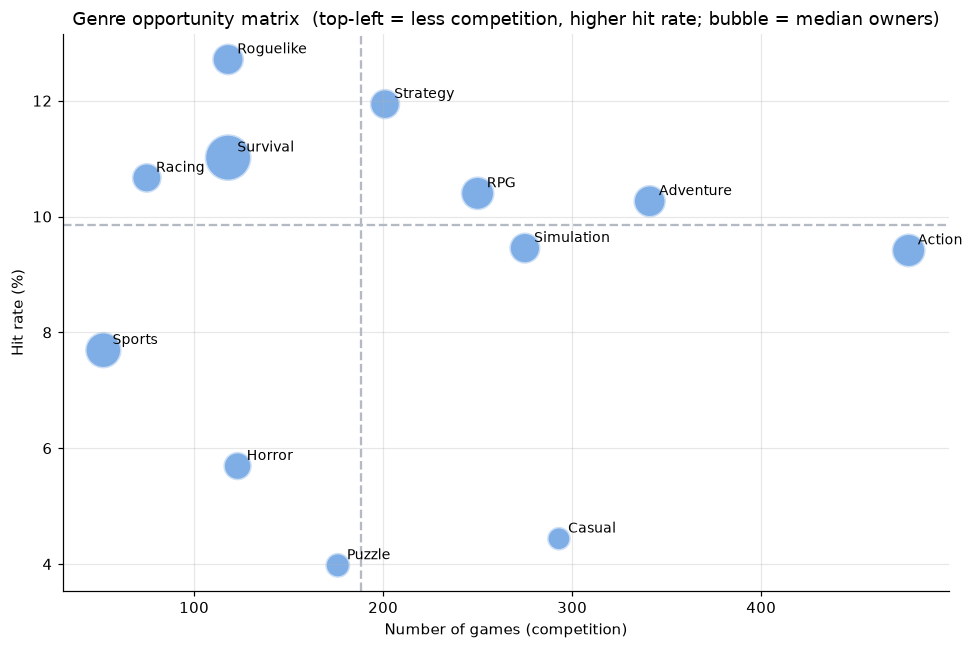

In [6]:
genre = df.groupby("primary_genre").agg(
    games=("app_id", "size"),
    median_owners=("owners_estimate", "median"),
    median_revenue=("estimated_revenue_usd", "median"),
    avg_review=("review_pct", "mean"),
    hit_rate=("is_hit", "mean"),
).sort_values("hit_rate", ascending=False)
genre["market_share_%"] = genre["games"] / genre["games"].sum() * 100
display(genre)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(genre["games"], genre["hit_rate"] * 100, s=genre["median_owners"] / genre["median_owners"].max() * 900 + 40,
           color=BLUE, alpha=.6, edgecolor="white", linewidth=2)
for g, r in genre.iterrows():
    ax.annotate(g, (r["games"], r["hit_rate"] * 100), xytext=(6, 4), textcoords="offset points", fontsize=9)
ax.axvline(genre["games"].median(), color=GRAY, ls="--")
ax.axhline(genre["hit_rate"].median() * 100, color=GRAY, ls="--")
ax.set_xlabel("Number of games (competition)")
ax.set_ylabel("Hit rate (%)")
ax.set_title("Genre opportunity matrix  (top-left = less competition, higher hit rate; bubble = median owners)")
save("03_genre_opportunity")

**Insight:** แนวเกมที่อยู่ **มุมซ้ายบน** (คู่แข่งน้อย + อัตราฮิตสูง) คือโอกาส เช่น Roguelike และ Survival (Strategy อัตราฮิตสูงแต่คู่แข่งเริ่มมาก)
ส่วนแนวที่มีเกมมากแต่อัตราฮิตต่ำ (เช่น Casual) คือ **ตลาดแข่งขันสูง (Red ocean)**

## 4. ตั้งราคาเท่าไรดี? (Q3)

,games,avg_review,median_owners,median_revenue,hit_rate
price_range,,,,,
Free,157.00,67.79,"51,200.00","34,539.00",0.08
< $5,734.00,73.72,"9,000.00","10,255.00",0.05
$5-10,478.00,75.68,"7,450.00","27,471.00",0.06
$10-20,535.00,75.29,"8,100.00","52,469.00",0.04
$20-40,73.00,76.49,"8,100.00","83,760.00",0.10
$40+,NaN,NaN,NaN,NaN,NaN


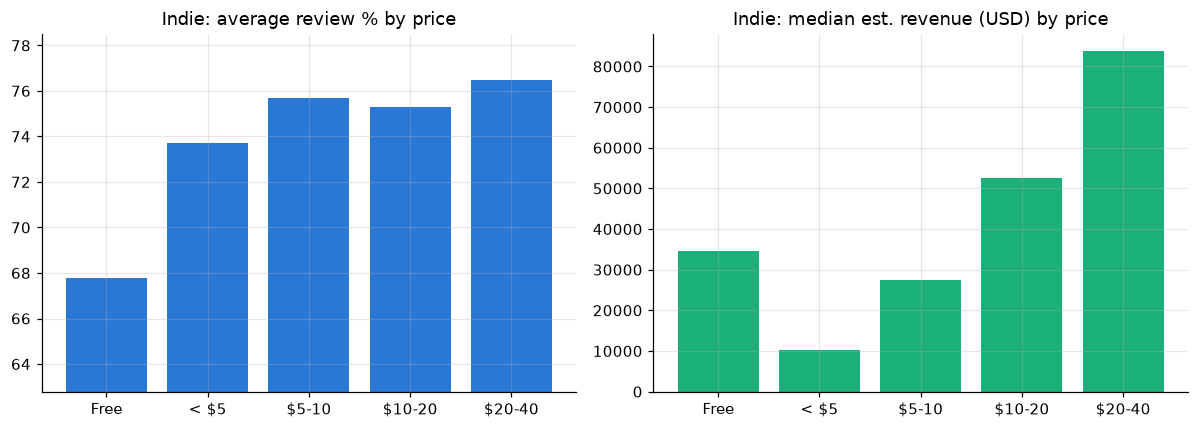

In [7]:
order = [p for p in ["Free", "< $5", "$5-10", "$10-20", "$20-40", "$40+"] if p in df["price_range"].unique()]
tier_filter = df["developer_tier"].eq("Indie") if "developer_tier" in df else slice(None)
indie = df[tier_filter]
price = indie.groupby("price_range").agg(
    games=("app_id", "size"),
    avg_review=("review_pct", "mean"),
    median_owners=("owners_estimate", "median"),
    median_revenue=("estimated_revenue_usd", "median"),
    hit_rate=("is_hit", "mean"),
).reindex(order)
display(price)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(price.index, price["avg_review"], color=BLUE)
axes[0].set_ylim(price["avg_review"].min() - 5, price["avg_review"].max() + 2)
axes[0].set_title("Indie: average review % by price")
axes[1].bar(price.index, price["median_revenue"], color=GREEN)
axes[1].set_title("Indie: median est. revenue (USD) by price")
save("04_indie_pricing")

## 5. Indie vs AA vs AAA — รายได้กระจุกตัวแค่ไหน? (Q4)

,games,revenue,median_revenue,hit_rate,share_games_%,share_revenue_%
developer_tier,,,,,,
AA,408,2168922261,"1,026,487.00",0.20,16.32,23.11
AAA,115,6951899459,"20,014,955.00",0.26,4.60,74.07
Indie,1977,264966742,"25,559.00",0.06,79.08,2.82


เกม top 1% ครองรายได้ 65.3% ของทั้งตลาด
เกม top 10% ครองรายได้ 95.9% ของทั้งตลาด
เกม top 20% ครองรายได้ 98.6% ของทั้งตลาด


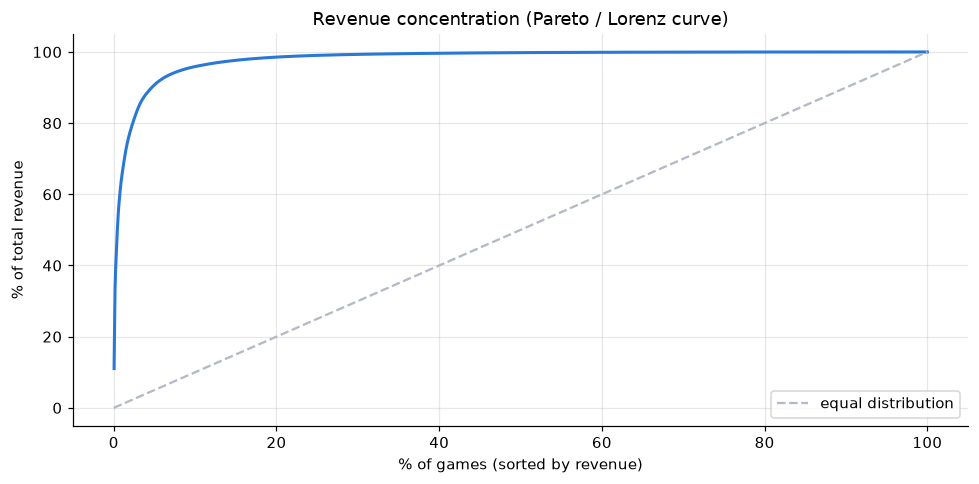

In [8]:
if "developer_tier" in df:
    tier = df.groupby("developer_tier").agg(games=("app_id", "size"), revenue=("estimated_revenue_usd", "sum"),
                                            median_revenue=("estimated_revenue_usd", "median"), hit_rate=("is_hit", "mean"))
    tier["share_games_%"] = tier["games"] / tier["games"].sum() * 100
    tier["share_revenue_%"] = tier["revenue"] / tier["revenue"].sum() * 100
    display(tier)

# Pareto: เกม top X% ครองรายได้กี่ %
rev = df["estimated_revenue_usd"].dropna().sort_values(ascending=False).reset_index(drop=True)
cum = rev.cumsum() / rev.sum() * 100
pct_games = (np.arange(1, len(rev) + 1) / len(rev)) * 100
for p in [1, 10, 20]:
    print(f"เกม top {p}% ครองรายได้ {cum.iloc[int(len(rev) * p / 100) - 1]:.1f}% ของทั้งตลาด")

fig, ax = plt.subplots()
ax.plot(pct_games, cum, color=BLUE, lw=2)
ax.plot([0, 100], [0, 100], color=GRAY, ls="--", label="equal distribution")
ax.set_xlabel("% of games (sorted by revenue)")
ax.set_ylabel("% of total revenue")
ax.set_title("Revenue concentration (Pareto / Lorenz curve)")
ax.legend()
save("05_revenue_pareto")

**Insight:** รายได้กระจุกตัวสูงมาก — เกมจำนวนน้อยครองรายได้ส่วนใหญ่ของตลาด (**hit-driven market**)
สำหรับสตูดิโออินดี้ ความเสี่ยงสูง ควรควบคุมต้นทุนการพัฒนาให้คุ้มทุนได้แม้ยอดขายระดับมัธยฐาน

## 6. Free-to-Play vs ขายขาด (Q5)

In [9]:
f2p = df.groupby("is_free").agg(games=("app_id", "size"), median_owners=("owners_estimate", "median"),
                                 avg_review=("review_pct", "mean"), median_revenue=("estimated_revenue_usd", "median"),
                                 hit_rate=("is_hit", "mean"))
f2p["revenue_per_owner"] = f2p["median_revenue"] / f2p["median_owners"]
f2p

,games,median_owners,avg_review,median_revenue,hit_rate,revenue_per_owner
is_free,,,,,,
Free,225,"98,100.00",67.90,"87,586.00",0.08,0.89
Paid,2275,"12,900.00",74.71,"44,412.00",0.09,3.44


**Insight:** เกม F2P ได้ผู้เล่นมากกว่าหลายเท่า แต่รีวิวเฉลี่ยต่ำกว่า และ **รายได้ต่อผู้เล่นต่ำกว่ามาก** (ดู `revenue_per_owner`) — ต้องมีระบบหารายได้ (monetization) ที่ดีและทีมดูแลระยะยาว ซึ่งยากสำหรับสตูดิโอเล็ก

## 7. ปัจจัยที่สัมพันธ์กับการเป็นเกมฮิต (Q6)

อัตราฮิตรวม = 8.9%


,factor,value,games,hit_rate_%,vs_overall_pp
14,developer_tier,AAA,115,26.09,17.17
13,developer_tier,AA,408,20.10,11.18
4,thai_language,Yes,241,16.60,7.68
10,steam_deck,Verified,867,10.50,1.58
1,multiplayer,Yes,648,9.88,0.96
5,early_access,No,2166,9.79,0.87
12,is_free,Paid,2275,8.97,0.05
0,multiplayer,No,1852,8.59,-0.33
11,is_free,Free,225,8.44,-0.48
7,steam_deck,Playable,1000,8.40,-0.52


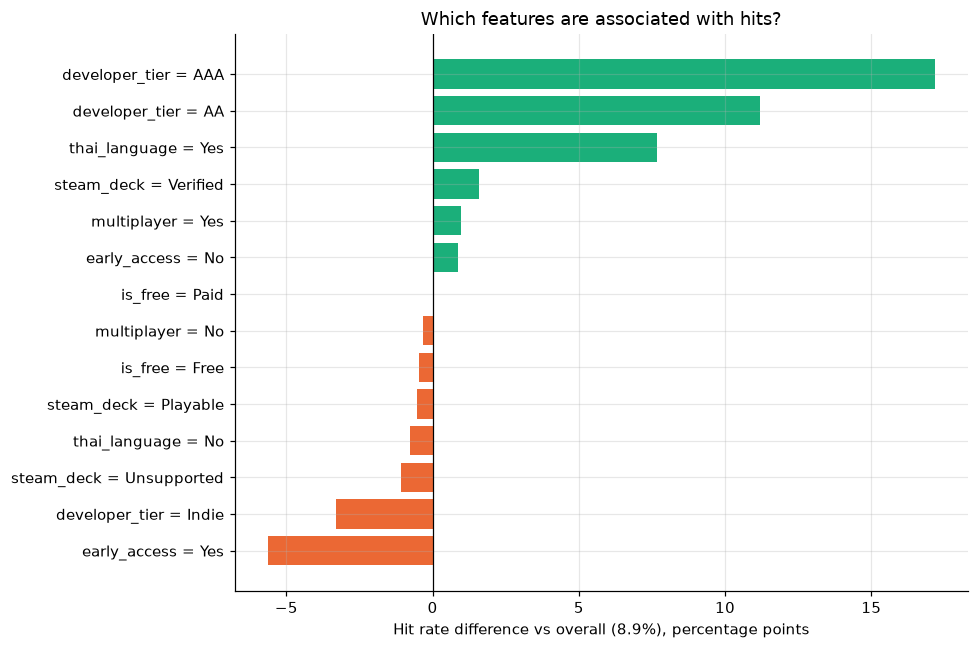

In [10]:
factors = [c for c in ["multiplayer", "thai_language", "early_access", "steam_deck", "is_free", "developer_tier"] if c in df]
rows = []
for c in factors:
    for v, g in df.groupby(c):
        rows.append({"factor": c, "value": v, "games": len(g), "hit_rate_%": g["is_hit"].mean() * 100})
fx = pd.DataFrame(rows)
overall = df["is_hit"].mean() * 100
fx["vs_overall_pp"] = fx["hit_rate_%"] - overall
print(f"อัตราฮิตรวม = {overall:.1f}%")
display(fx.sort_values("vs_overall_pp", ascending=False))

sub = fx[fx["games"] >= 30].sort_values("vs_overall_pp")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(sub["factor"] + " = " + sub["value"].astype(str), sub["vs_overall_pp"],
        color=[GREEN if v > 0 else ORANGE for v in sub["vs_overall_pp"]])
ax.axvline(0, color="black", lw=.8)
ax.set_xlabel(f"Hit rate difference vs overall ({overall:.1f}%), percentage points")
ax.set_title("Which features are associated with hits?")
save("06_hit_factors")

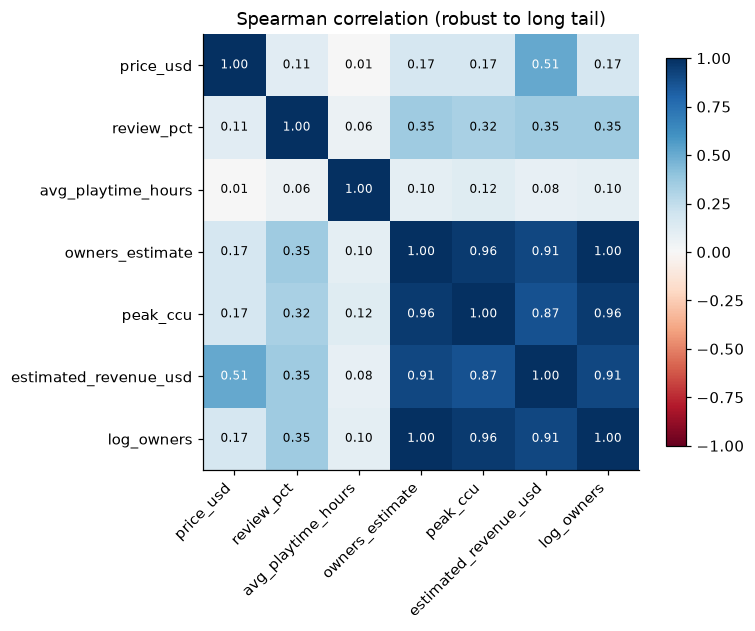

In [11]:
num_cols = ["price_usd", "review_pct", "avg_playtime_hours", "owners_estimate", "peak_ccu", "estimated_revenue_usd"]
num_cols = [c for c in num_cols if c in df]
corr = df[num_cols].assign(log_owners=np.log10(df["owners_estimate"].clip(lower=1))).corr(method="spearman")
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(corr.iloc[i, j]) > .5 else "black")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=.8)
ax.set_title("Spearman correlation (robust to long tail)")
save("07_correlation")

> ⚠️ **Correlation ≠ Causation** — เช่น เกมที่รองรับภาษาไทยอาจฮิตกว่าเพราะเป็นเกมทุนสูงอยู่แล้ว (ตัวแปรกวน: `developer_tier`)
> ลองแยกวิเคราะห์เฉพาะ Indie เพื่อควบคุมตัวแปรนี้

In [12]:
if "developer_tier" in df:
    ind = df[df["developer_tier"] == "Indie"]
    display(pd.concat({c: ind.groupby(c)["is_hit"].mean().mul(100).round(1) for c in ["multiplayer", "thai_language", "early_access"]}))

multiplayer    No        5.50
               Yes       6.10
thai_language  No        5.50
               Unknown   0.00
               Yes       9.00
early_access   No        6.10
               Yes       3.30
Name: is_hit, dtype: float64

## 8. สรุปตัวเลขสำคัญ (สำหรับใส่ในบทสรุป / KPI ในแดชบอร์ด)

In [13]:
best_genre = genre.index[0]
best_price = price["median_revenue"].idxmax()
summary = pd.Series({
    "จำนวนเกมที่วิเคราะห์": f"{len(df):,}",
    "อัตราเกมฮิตรวม": f"{overall:.1f}%",
    "มัธยฐานผู้เล่นต่อเกม": f"{df['owners_estimate'].median():,.0f}",
    "มัธยฐานรายได้ประมาณการ (USD)": f"{df['estimated_revenue_usd'].median():,.0f}",
    "เกม top 10% ครองรายได้": f"{cum.iloc[int(len(rev) * .1) - 1]:.1f}%",
    "แนวเกมอัตราฮิตสูงสุด": f"{best_genre} ({genre.loc[best_genre, 'hit_rate'] * 100:.1f}%)",
    "ช่วงราคาอินดี้ที่รายได้มัธยฐานสูงสุด": best_price,
})
summary.to_frame("ค่า")

,ค่า
จำนวนเกมที่วิเคราะห์,"2,500"
อัตราเกมฮิตรวม,8.9%
มัธยฐานผู้เล่นต่อเกม,"14,950"
มัธยฐานรายได้ประมาณการ (USD),"46,497"
เกม top 10% ครองรายได้,95.9%
แนวเกมอัตราฮิตสูงสุด,Roguelike (12.7%)
ช่วงราคาอินดี้ที่รายได้มัธยฐานสูงสุด,$20-40


In [14]:
# Export ตารางสรุปไปใช้ต่อใน Power BI / Excel / รายงาน
out = ROOT / "analysis" / "output"
out.mkdir(exist_ok=True)
genre.to_csv(out / "genre_summary.csv", encoding="utf-8-sig")
price.to_csv(out / "indie_price_summary.csv", encoding="utf-8-sig")
fx.to_csv(out / "hit_factors.csv", index=False, encoding="utf-8-sig")
df.to_csv(out / "games_clean.csv", index=False, encoding="utf-8-sig")
print("บันทึกแล้ว:", [p.name for p in out.iterdir()])

บันทึกแล้ว: ['hit_factors.csv', 'indie_price_summary.csv', 'games_clean.csv', 'genre_summary.csv']


## 9. ข้อเสนอแนะ (Recommendations) — ตัวอย่าง
เขียนให้ **ตรวจสอบกับตัวเลขข้างบนทุกครั้ง** หากเปลี่ยนเป็นข้อมูลจริง

1. **แนวเกม:** เลือกแนวที่คู่แข่งน้อยแต่อัตราฮิตสูง (มุมซ้ายบนของ Opportunity matrix) แทนแนวที่ตลาดล้น
2. **ราคา:** เกมอินดี้ควรตั้งราคาในช่วงที่รีวิวและรายได้มัธยฐานดีที่สุด ไม่ควรตั้งถูกเกินไปเพราะไม่ได้ช่วยให้ขายได้มากขึ้นอย่างมีนัย
3. **ฟีเจอร์:** การรองรับ **ภาษาไทย/หลายภาษา** สัมพันธ์กับอัตราฮิตที่สูงกว่าชัดเจน แม้จะดูเฉพาะเกมอินดี้ ส่วน Multiplayer และ Steam Deck ต่างกันเพียงเล็กน้อย (~1 จุด %) จึงไม่ควรใช้เป็นเหตุผลหลัก
4. **Early Access:** เกมที่อยู่ใน Early Access มีอัตราฮิตต่ำกว่า — ถ้าจะใช้ ต้องมีแผนอัปเดตที่ชัดเจนเพื่อรักษารีวิว
5. **ความเสี่ยง:** ตลาดเป็นแบบ hit-driven ควรวางงบให้คุ้มทุนที่ยอดขายระดับมัธยฐาน และทดสอบตลาดก่อน (เช่น demo / wishlist / Early Access)

### ข้อจำกัด
- ยอดผู้เล่นและรายได้เป็น **ค่าประมาณ** (SteamSpy ให้เป็นช่วง) ไม่ใช่ยอดขายจริง
- ความสัมพันธ์ที่พบเป็น correlation ไม่ได้พิสูจน์ว่าเป็นสาเหตุ
- เกมที่ออกก่อนมีเวลาสะสมผู้เล่นนานกว่า (time bias)